#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [ ]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

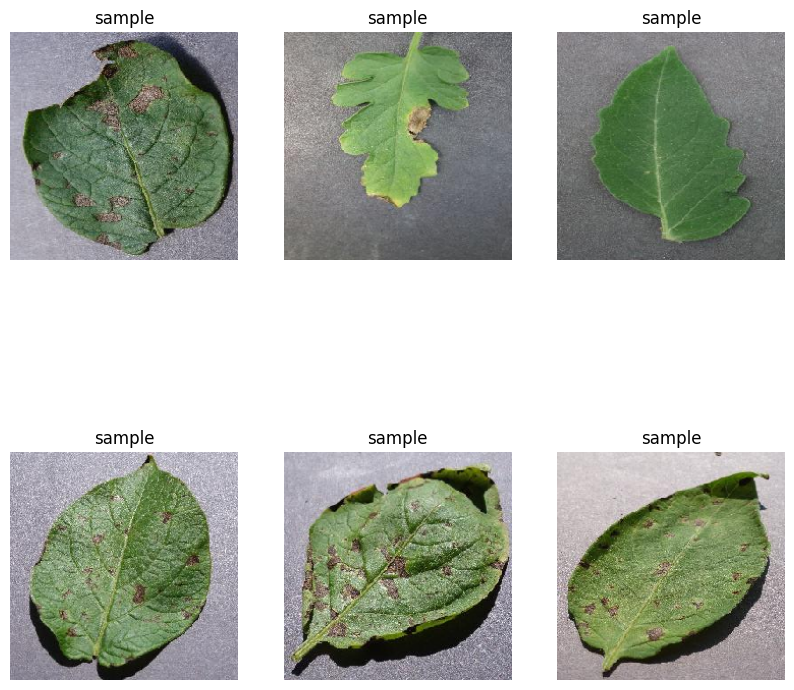

In [ ]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [ ]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.3417 - loss: 3.0855 - val_accuracy: 0.5733 - val_loss: 1.0901
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.8217 - loss: 0.5579 - val_accuracy: 0.8533 - val_loss: 0.4468
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9400 - loss: 0.1896 - val_accuracy: 0.9333 - val_loss: 0.2455
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9867 - loss: 0.0579 - val_accuracy: 0.9533 - val_loss: 0.2000
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9967 - loss: 0.0231 - val_accuracy: 0.9600 - val_loss: 0.2260
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9983 - loss: 0.0097 - val_accuracy: 0.9667 - val_loss: 0.2003
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9267 - val_loss: 0.2656
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9467 - val_loss:

# Plot Accuracy & Loss

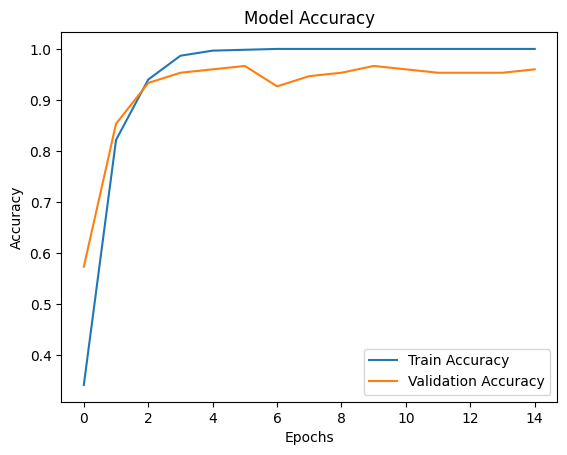

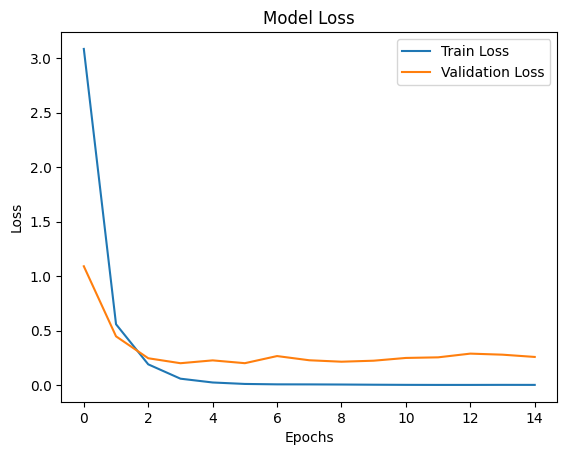

In [ ]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()